## ---------------------------------------------------------
## STAGE 0: Setup
## ---------------------------------------------------------

In [4]:
!pip install sentence-transformers datasets accelerate seaborn tqdm
from sentence_transformers import CrossEncoder, InputExample
from datasets import load_dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np
import math
import torch
from torch import nn
from accelerate import notebook_launcher
import os
import random
import re
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm
import gc
import json

In [5]:
def p_tagger(text):
    P_REGEX = r'\b(p(?:-value)?)\s*([<>=])\s*([0-9]*\.?[0-9])'
    def replace_match(match):
        p_prefix = match.group(1)
        operator = match.group(2)
        val_str = match.group(3)
        try:
            val = float(val_str)
            if val <= 0.05:
                tag = "[STATISTICALLY SIGNIFICANT]"
            elif 0.05 < val <= 0.10:
                tag = "[BORDERLINE SIGNIFICANCE]"
            else:
                tag = "[NOT SIGNIFICANT]"
            return f"{tag} {p_prefix} {operator} {val_str}"
        except ValueError:
            return match.group(0) 
    return re.sub(P_REGEX, replace_match, text, flags=re.IGNORECASE)

def extract_results(row):
    labels = row['context']['labels']
    contexts = row['context']['contexts']
    results = []
    text = None
    for i, label in enumerate(labels):
        l = label.upper()
        if l in ["RESULT", "RESULTS"]:
            text = contexts[i]
    if text is None:
        text = contexts[-1]
    text = p_tagger(text)
    return text

label_map = {"no": 0, "maybe": 1, "yes": 2}
print("Downloading datasets from Hugging Face...")
art_dataset_full = load_dataset("pubmed_qa", "pqa_artificial", split='train')
labeled_dataset = load_dataset("pubmed_qa", "pqa_labeled", split='train')
unlabeled_dataset = load_dataset("pubmed_qa", "pqa_unlabeled", split='train')

# Artificial Data
art_yes = [row for row in art_dataset_full if row['final_decision'] == 'yes']
art_no = [row for row in art_dataset_full if row['final_decision'] == 'no']
random.seed(42)
balanced_art_data = random.sample(art_yes, 5000) + random.sample(art_no, 5000)

art_samples_normal = []
art_samples_teacher = []
for row in tqdm(balanced_art_data, desc="Processing Artificial"):
    res_context = extract_results(row) 
    art_samples_normal.append(InputExample(
        texts=[f"[QUESTION] {row['question']}", f"[CONTEXT] {res_context}"],
        label=label_map[row['final_decision']]
    ))
    art_samples_teacher.append(InputExample(
        texts=[f"[QUESTION] {row['question']}", f"[CONCLUSION] {row['long_answer']}"], 
        label=label_map[row['final_decision']]
    ))

# Labeled Data
labeled_samples_normal = []
labeled_samples_teacher = []
for row in tqdm(labeled_dataset, desc="Processing Labeled"):
    res_context = extract_results(row)
    labeled_samples_normal.append(InputExample(
        texts=[f"[QUESTION] {row['question']}", f"[CONTEXT] {res_context}"],
        label=label_map[row['final_decision']]
    ))
    labeled_samples_teacher.append(InputExample(
        texts=[f"[QUESTION] {row['question']}", f"[CONCLUSION] {row['long_answer']}"], 
        label=label_map[row['final_decision']]
    ))

# Unlabeled Data
unlabeled_samples_teacher = []
u_subset = unlabeled_dataset.shuffle(seed=42) 
for row in tqdm(u_subset, desc="Processing Unlabeled Teacher"):
    unlabeled_samples_teacher.append([f"[QUESTION] {row['question']}", f"[CONCLUSION] {row['long_answer']}"])

print(f"\nSuccessfully loaded:")
print(f"- Art Normal/Teacher: {len(art_samples_normal)}")
print(f"- Labeled Normal/Teacher: {len(labeled_samples_normal)}")
print(f"- Unlabeled Teacher: {len(unlabeled_samples_teacher)}")

Processing Artificial:   0%|          | 0/10000 [00:00<?, ?it/s]

Processing Labeled:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing Unlabeled Teacher:   0%|          | 0/61249 [00:00<?, ?it/s]


Successfully loaded:
- Art Normal/Teacher: 10000
- Labeled Normal/Teacher: 1000
- Unlabeled Teacher: 61249


## ---------------------------------------------------------
## STAGE 1: Pre-training on Artificial (PQA-A)
## ---------------------------------------------------------

In [6]:
print("Stage 1: Training on Artificial Data...")
art_dataloader = DataLoader(art_samples_normal, shuffle=True, batch_size=16)
loss_stage1 = nn.CrossEntropyLoss(label_smoothing=0.1)
model_name = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
model_tertiary = CrossEncoder(model_name, num_labels=3, max_length=512)
new_tokens = ["[STATISTICALLY SIGNIFICANT]", "[BORDERLINE SIGNIFICANCE]", "[NOT SIGNIFICANT]"]
model_tertiary.tokenizer.add_special_tokens({'additional_special_tokens': new_tokens})
model_tertiary.model.resize_token_embeddings(len(model_tertiary.tokenizer))
model_tertiary.fit(
    train_dataloader=art_dataloader,
    epochs=1,
    loss_fct=loss_stage1,
    optimizer_params={'lr': 8e-6},
    warmup_steps=100)

model_path = 'stage1_art'
model_tertiary.save(model_path)

Stage 1: Training on Artificial Data...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Step,Training Loss
500,0.660299


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## ---------------------------------------------------------
## STAGE 2: Train Teacher and Pseudo-Label Acquisition
## ---------------------------------------------------------

In [7]:
# Artificial Teacher
model_teacher = CrossEncoder(model_name, num_labels=3, max_length=512)
art_teacher_dataloader = DataLoader(art_samples_teacher, shuffle=True, batch_size=8)
model_teacher.fit(
    train_dataloader=art_teacher_dataloader, 
    epochs=2, 
    loss_fct=nn.CrossEntropyLoss(label_smoothing=0.1), 
    optimizer_params={'lr': 8e-6},
    warmup_steps=math.ceil(len(art_teacher_dataloader) * 3 * 0.1)
)

# Labeled Teacher
all_teacher_labels = [ex.label for ex in labeled_samples_teacher]
class_counts = np.bincount(all_teacher_labels)
class_weights = 1.0 / (class_counts)
sample_weights = [class_weights[l] for l in all_teacher_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)
labeled_dataloader = DataLoader(labeled_samples_teacher, batch_size=16, sampler=sampler)
print("Stage 2: Teacher on Labeled Data...")
model_teacher.fit(
    train_dataloader=labeled_dataloader,
    epochs=8, 
    optimizer_params={'lr': 8e-6},
    warmup_steps=math.ceil(len(labeled_dataloader) * 12 * 0.1)
)

# Unlabeled Teacher
print("Stage 2: Collecting Pseudo-labels on Unlabeled with Teacher...")
raw_scores = model_teacher.predict(unlabeled_samples_teacher, show_progress_bar=True, batch_size=8)
probs = F.softmax(torch.tensor(raw_scores), dim=1).numpy()
confidences = np.max(probs, axis=1)
predicted_labels = np.argmax(probs, axis=1)

class_pools = {0: [], 1: [], 2: []}
for i, pred_label in enumerate(predicted_labels):
    class_pools[pred_label].append((i, confidences[i]))
for lbl in class_pools:
    class_pools[lbl].sort(key=lambda x: x[1], reverse=True)

targets = {0: 2250, 1: 1500, 2: 2250}
pseudo_labeled_samples = []

print(f"\n{'Class':<10} | {'Selected':<10} | {'Min Conf':<10}")
print("-" * 35)
for label, limit in targets.items():
    selected = class_pools[label][:limit]
    if not selected: continue
    min_c = selected[-1][1]
    class_name = ["NO", "MAYBE", "YES"][label]
    print(f"{class_name:<10} | {len(selected):<10} | {min_c:.4f}")
    for idx, conf in selected:
        row = u_subset[int(idx)]
        res_context = extract_results(row) 
        pseudo_labeled_samples.append(InputExample(
            texts=[f"[QUESTION] {row['question']}", f"[CONTEXT] {res_context}"],
            label=int(label)
        ))
print(f"\nTotal pseudo-labeled samples: {len(pseudo_labeled_samples)}")

pseudo_dataloader = DataLoader(pseudo_labeled_samples, shuffle=True, batch_size=32)
model_tertiary = CrossEncoder('stage1_art', num_labels=3, max_length=512)
model_tertiary.fit(
    train_dataloader=pseudo_dataloader,
    epochs=4, 
    loss_fct=nn.CrossEntropyLoss(label_smoothing=0.05),
    optimizer_params={'lr': 8e-6},
    warmup_steps=math.ceil(len(pseudo_dataloader) * 4 * 0.1)
)
model_tertiary.save('stage2_pseudo')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Step,Training Loss
500,0.627221
1000,0.413332
1500,0.377473
2000,0.374089
2500,0.355874


Stage 2: Teacher on Labeled Data...


Step,Training Loss
500,0.430823


...

Batches:   0%|          | 0/7657 [00:00<?, ?it/s]


Class      | Selected   | Min Conf  
-----------------------------------
NO         | 2250       | 0.9773
MAYBE      | 1500       | 0.9695
YES        | 2250       | 0.9568

Total pseudo-labeled samples: 6000


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss
500,0.523855


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## ---------------------------------------------------------
## STAGE 3: Fine-Tuning on Labeled (PQA-L)
## ---------------------------------------------------------

In [11]:
with open('ground_truth_test.json', 'r') as f:
    ground_truth = json.load(f)
test_ids = set(ground_truth.keys())

official_test_samples, official_dev_samples = [], []
for row in labeled_dataset:
    pubid_str = str(row['pubid'])
    res_context = extract_results(row)
    example = InputExample(texts=[row['question'], res_context], label=label_map[row['final_decision']])
    if pubid_str in test_ids: official_test_samples.append(example)
    else: official_dev_samples.append(example)

dev_samples_np = np.array(official_dev_samples, dtype=object)
dev_labels_np = np.array([ex.label for ex in official_dev_samples])
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha 
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt)**self.gamma * ce_loss
        return loss.mean()

for fold, (train_idx, val_idx) in enumerate(skf.split(dev_samples_np, dev_labels_np)):
    print(f"\n--- Training Official Fold {fold + 1} / 10 ---")
    model = CrossEncoder('stage2_pseudo', num_labels=3)
    train_loader = DataLoader(dev_samples_np[train_idx].tolist(), shuffle=True, batch_size=16)
    val_fold = dev_samples_np[val_idx].tolist()
    val_labels = [ex.label for ex in val_fold]
    val_pairs = [[ex.texts[0], ex.texts[1]] for ex in val_fold]

    model.fit(
        train_dataloader=train_loader,
        epochs=6,
        loss_fct= FocalLoss(gamma=1.5, alpha=torch.tensor([1.0, 0.9, 1.0]).cuda()),
        optimizer_params={'lr': 8e-6},
        weight_decay=0.02,
        warmup_steps=math.ceil(len(train_loader) * 6 * 0.1)
    )
    
    preds = np.argmax(model.predict(val_pairs), axis=1)
    acc = accuracy_score(val_labels, preds)
    f1 = f1_score(val_labels, preds, average='macro')
    fold_results.append({'acc': acc, 'f1': f1})
    
    print(f"Fold {fold+1} Finished. Acc: {acc:.4f}, Macro F1: {f1:.4f}")
    model.save(f'pubmedqa_fold_{fold}')
    del model
    gc.collect()

avg_acc = np.mean([f['acc'] for f in fold_results])
avg_f1 = np.mean([f['f1'] for f in fold_results])
print(f"\nOfficial CV Mean Accuracy: {avg_acc:.4f}")
print(f"Official CV Mean Macro F1: {avg_f1:.4f}")


--- Training Official Fold 1 / 10 ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss


Fold 1 Finished. Acc: 0.7200, Macro F1: 0.5996


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Step,Training Loss


Fold 10 Finished. Acc: 0.6800, Macro F1: 0.4756


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Official CV Mean Accuracy: 0.7160
Official CV Mean Macro F1: 0.5205


In [12]:
test_pairs = [[ex.texts[0], ex.texts[1]] for ex in official_test_samples]
test_labels = [ex.label for ex in official_test_samples]
gc.collect()

all_model_logits = []
print("Starting Ensemble Inference across 10 models...")
for i in range(10):
    print(f"Processing Model {i}...")
    model = CrossEncoder(f'pubmedqa_fold_{i}')
    logits = model.predict(test_pairs, convert_to_numpy=True, show_progress_bar=False)
    all_model_logits.append(logits)

mean_logits = np.mean(all_model_logits, axis=0)
final_preds = np.argmax(mean_logits, axis=1)

print("\n" + "="*40)
print("OFFICIAL 10-FOLD ENSEMBLE BENCHMARK RESULTS")
print("="*40)
print(classification_report(test_labels, final_preds, target_names=["no", "maybe", "yes"]))

Starting Ensemble Inference across 10 models...
Processing Model 0...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Processing Model 1...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Processing Model 2...


...

Processing Model 8...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Processing Model 9...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


OFFICIAL 10-FOLD ENSEMBLE BENCHMARK RESULTS
              precision    recall  f1-score   support

          no       0.68      0.65      0.66       169
       maybe       0.23      0.09      0.13        55
         yes       0.74      0.84      0.79       276

    accuracy                           0.70       500
   macro avg       0.55      0.53      0.53       500
weighted avg       0.66      0.70      0.67       500



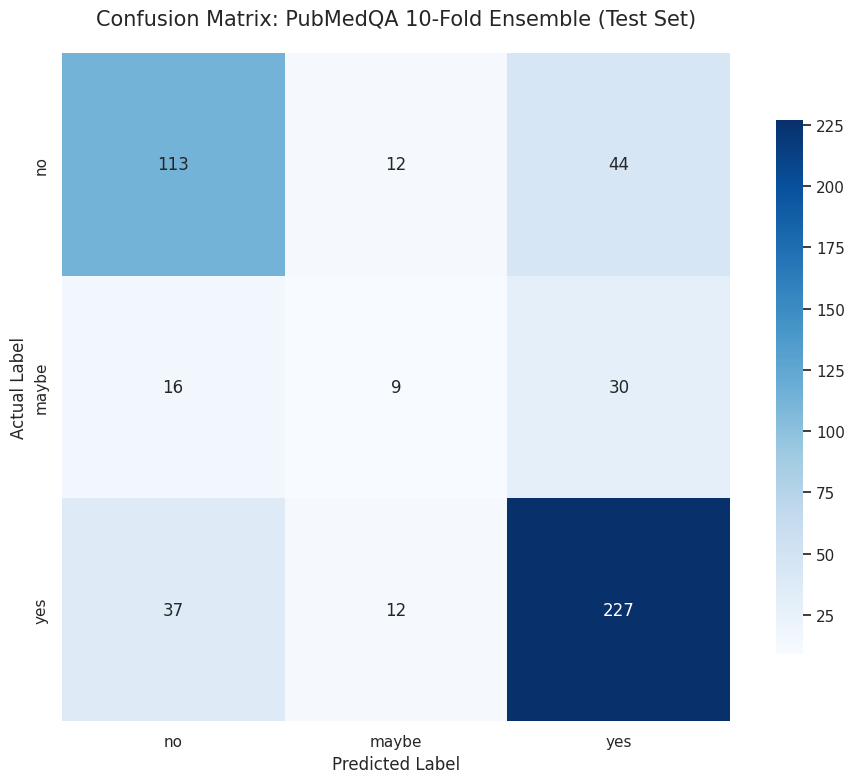

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = ["no", "maybe", "yes"]
cm = confusion_matrix(test_labels, final_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Confusion Matrix: PubMedQA 10-Fold Ensemble (Test Set)', fontsize=15, pad=20)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig("test_set_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_test_scores = mean_logits 
all_test_probs = np.exp(all_test_scores) / np.sum(np.exp(all_test_scores), axis=1, keepdims=True)
all_test_preds = np.argmax(all_test_probs, axis=1)
maybe_indices = np.where(all_test_preds == 1)[0]

if len(maybe_indices) == 0:
    print("No 'maybe' predictions found in the test set.")
else:
    selected_indices = maybe_indices[:10]
    class_names = ["no", "maybe", "yes"]
    colors = ['#ff9999', '#ffcc99', '#66b3ff']
    fig, axes = plt.subplots(2, 5, figsize=(18, 9), sharey=True)
    for i, idx in enumerate(selected_indices):
        row = i // 5
        col = i % 5
        ax = axes[row, col]
        prob_dist = all_test_probs[idx]
        pred_idx = all_test_preds[idx]
        true_label_str = class_names[test_labels[idx]]
        bars = ax.bar(class_names, prob_dist, color=colors)
        ax.set_title(f"(Idx {idx})\nTrue: {true_label_str}\nPred: {class_names[pred_idx]}", fontsize=10)
        ax.set_ylim(0, 1.1)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle("First 10 'Maybe' Predictions (Test Set)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

NameError: name 'mean_logits' is not defined

In [66]:
import re

def p_tagger(text):
    P_REGEX = r'\b(p(?:-value)?)\s*([<>=])\s*([0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?)'
    def replace_match(match):
        p_prefix = match.group(1)
        operator = match.group(2)
        val_str = match.group(3)
        try:
            val = float(val_str)
            if val <= 0.05:
                tag = "[STATISTICALLY SIGNIFICANT]"
            elif 0.05 < val <= 0.10:
                tag = "[BORDERLINE SIGNIFICANCE]"
            else:
                tag = "[NOT SIGNIFICANT]"
            return f"{tag} {p_prefix} {operator} {val_str}"
        except ValueError:
            return match.group(0) 
    return re.sub(P_REGEX, replace_match, text, flags=re.IGNORECASE)

sample = "The result was p = 0.06, while another test showed p < .001."
print(p_tagger(sample))

The result was [BORDERLINE SIGNIFICANCE] p = 0.06, while another test showed [STATISTICALLY SIGNIFICANT] p < .001.


In [72]:
import re
from datasets import load_dataset
from tqdm.auto import tqdm

dataset = load_dataset("pubmed_qa", "pqa_labeled", split='train')
total_cases = len(dataset)
ci_only_cases = 0
p_and_ci_cases = 0
p_only_cases = 0
no_stats_cases = 0

P_VALUE_PATTERN = r'(?i)\b(p(?:-value)?)\s*[<>=]\s*[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?'
CI_PATTERN = r'(?i)\b(ci|confidence interval)\b\s*[:=\(\[]?\s*[-+]?[0-9]*\.?[0-9]+'
print(f"Trawling {total_cases} samples for independent statistical profiles...")

for example in tqdm(dataset):
    labels = example['context']['labels']
    contexts = example['context']['contexts']
    
    results_text = None
    for i, label in enumerate(labels):
        if label.upper() in ["RESULT", "RESULTS"]:
            results_text = contexts[i]
            break
    
    full_text = results_text if results_text else contexts[-1]
    has_p = bool(re.search(P_VALUE_PATTERN, full_text))
    has_ci = bool(re.search(CI_PATTERN, full_text))
            
    if has_ci and not has_p:
        ci_only_cases += 1
    elif has_ci and has_p:
        p_and_ci_cases += 1
    elif has_p and not has_ci:
        p_only_cases += 1
    else:
        no_stats_cases += 1

# 5. Final Report
print("-" * 35)
print(f"Total Samples:            {total_cases}")
print(f"P-value ONLY:             {p_only_cases} ({p_only_cases/total_cases:.1%})")
print(f"CI ONLY (No P):           {ci_only_cases} ({ci_only_cases/total_cases:.1%})")
print(f"Both P and CI:            {p_and_ci_cases} ({p_and_ci_cases/total_cases:.1%})")
print(f"No detected Stats:        {no_stats_cases} ({no_stats_cases/total_cases:.1%})")

Trawling 1000 samples for independent statistical profiles...


  0%|          | 0/1000 [00:00<?, ?it/s]

-----------------------------------
Total Samples:            1000
P-value ONLY:             375 (37.5%)
CI ONLY (No P):           63 (6.3%)
Both P and CI:            57 (5.7%)
No detected Stats:        505 (50.5%)
